# Optimizacion con Optuna: lectura de resultados y evaluacion en test

Este notebook **lee los trials de Optuna ya generados** (`optuna_trials.csv`,
para los escenarios con y sin exogenas) y la **configuracion ganadora**
(`best_config.json`), produce las figuras de convergencia / importancia, y
evalua honestamente la mejor config sobre el **test 2022+**.

**Metodologia (split en 3 vias):**
- **Train** (≤2019): ajuste
- **Validacion** (2020-2021): Optuna optimiza aqui (con TimeSeriesSplit)
- **Test** (2022+): evaluacion final, INTACTO durante la busqueda

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":150,"font.size":11,
    "axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,
    "axes.spines.right":False,"figure.autolayout":True})
C = {"trial":"#888780","best":"#534AB7","imp":"#1D9E75",
     "real":"#222222","pred":"#D85A30","blue":"#378ADD"}

PROC, MODELS, FIG = "../data/processed", "../models", "../reports/figures"
import os; os.makedirs(FIG, exist_ok=True)
DATA = "../data/interim/berry_features.csv"

In [2]:
# Autodeteccion de la raiz del proyecto (funciona desde notebooks/ o notebooks/<sub>/)
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT/"data"/"interim").exists():
    ROOT = ROOT.parent
DATA   = str(ROOT/"data"/"interim"/"berry_features.csv")
PROC   = str(ROOT/"data"/"processed")
MODELS = str(ROOT/"models")
FIG    = str(ROOT/"reports"/"figures")
import os; os.makedirs(FIG, exist_ok=True)
print("ROOT:", ROOT)

ROOT: /home/makenly/Escritorio/berry-price-tda


## 1. Trials de Optuna (con y sin exogenas)

In [3]:
trials_sin = pd.read_csv(f"{PROC}/sin_exog/optuna_trials.csv")
trials_con = pd.read_csv(f"{PROC}/con_exog/optuna_trials.csv")

for name, t in [("SIN exog", trials_sin), ("CON exog", trials_con)]:
    best = t.loc[t["value"].idxmin()]
    print(f"{name}: {len(t)} trials | mejor valor (penalizado) = {best['value']:.3f} "
          f"en trial #{int(best['number'])}")
trials_sin.head()

SIN exog: 500 trials | mejor valor (penalizado) = 22.843 en trial #63
CON exog: 500 trials | mejor valor (penalizado) = 22.587 en trial #434


,number,value,datetime_start,datetime_complete,duration,params_model,params_strategy,params_transform,params_use_tda,params_window,state
0,0,22.994194,2026-06-08 09:33:33.897564,2026-06-08 09:33:34.763274,0 days 00:00:00.865710,Ridge,none,log_diff,True,12,COMPLETE
1,1,38.136558,2026-06-08 09:33:33.899710,2026-06-08 09:33:34.923891,0 days 00:00:01.024181,ElasticNet,none,seasonal_diff,True,24,COMPLETE
2,2,29.517389,2026-06-08 09:33:33.900151,2026-06-08 09:33:35.134910,0 days 00:00:01.234759,Ridge,exclude,standard,True,24,COMPLETE
3,3,26.608707,2026-06-08 09:33:33.901598,2026-06-08 09:33:34.299978,0 days 00:00:00.398380,Lasso,dummy,standard,False,36,COMPLETE
4,4,24.330172,2026-06-08 09:33:33.906663,2026-06-08 09:33:37.984087,0 days 00:00:04.077424,KNN,winsorize,standard,False,24,COMPLETE


## 2. Convergencia de la busqueda

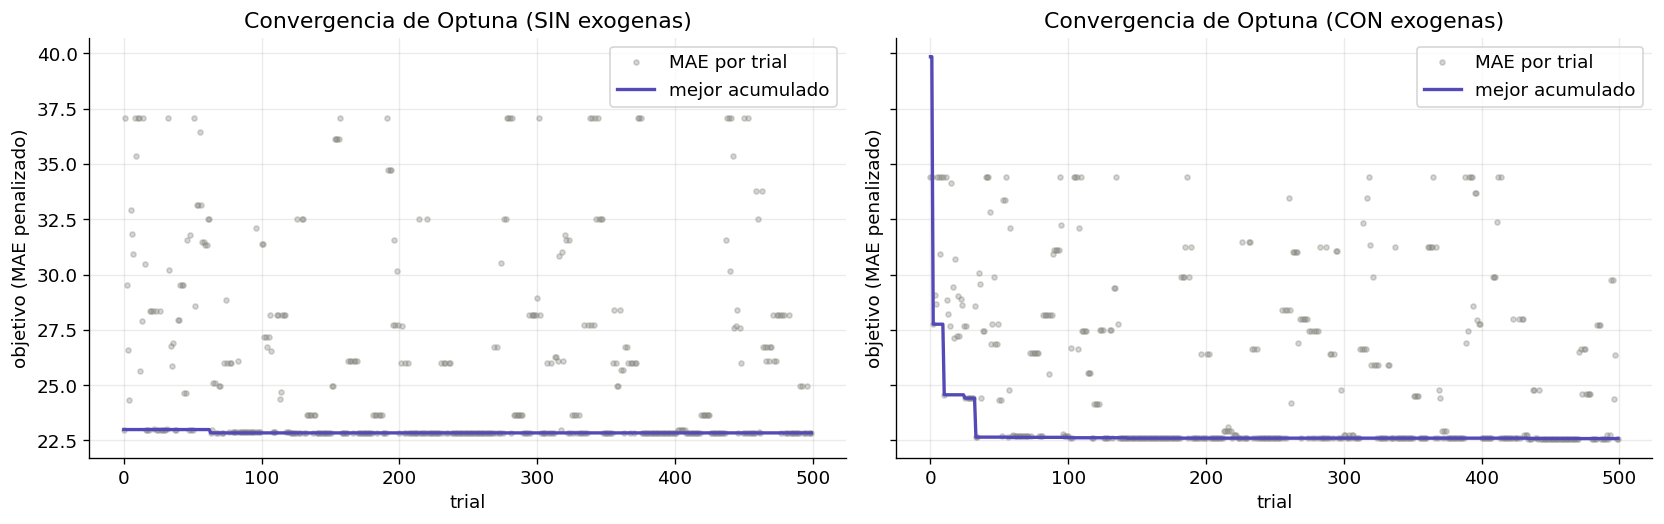

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, t, ttl in [(axes[0], trials_sin, "SIN exogenas"),
                   (axes[1], trials_con, "CON exogenas")]:
    vals = t["value"].clip(upper=t["value"].quantile(0.95)).values
    best_so_far = pd.Series(t["value"].values).cummin()
    ax.plot(vals, "o", ms=3, alpha=0.35, color=C["trial"], label="MAE por trial")
    ax.plot(best_so_far, "-", lw=2, color=C["best"], label="mejor acumulado")
    ax.set(title=f"Convergencia de Optuna ({ttl})", xlabel="trial", ylabel="objetivo (MAE penalizado)")
    ax.legend()
plt.savefig(f"{FIG}/fig_optuna_convergencia.png", bbox_inches="tight")
plt.show()

## 3. Importancia de los factores

Recalculamos la importancia de hiperparametros a partir de los trials
(fANOVA via Optuna si esta disponible; si no, varianza explicada por factor).

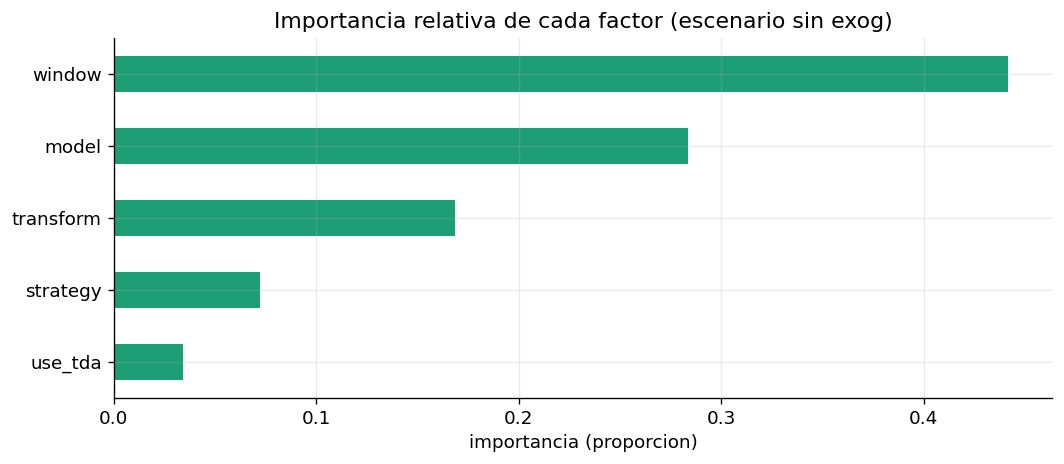

window       0.442
model        0.283
transform    0.169
strategy     0.072
use_tda      0.034
dtype: float64

In [5]:
def importancia_fallback(t):
    # Importancia aproximada: reduccion de varianza del objetivo por factor
    pcols = [c for c in t.columns if c.startswith("params_")]
    base = t["value"].var()
    imp = {}
    for p in pcols:
        grp = t.groupby(p)["value"].mean()
        # varianza entre-grupos ponderada
        w = t.groupby(p)["value"].count() / len(t)
        between = ((grp - t["value"].mean())**2 * w).sum()
        imp[p.replace("params_","")] = between / base if base else 0
    s = pd.Series(imp).sort_values()
    return s / s.sum()

imp = importancia_fallback(trials_sin)
fig, ax = plt.subplots(figsize=(9, 4))
imp.plot(kind="barh", ax=ax, color=C["imp"])
ax.set(title="Importancia relativa de cada factor (escenario sin exog)",
       xlabel="importancia (proporcion)")
plt.savefig(f"{FIG}/fig_optuna_importancia.png", bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False).round(3)

## 4. Configuraciones ganadoras

In [6]:
cfg_sin = json.load(open(f"{MODELS}/sin_exog/best_config.json"))
cfg_con = json.load(open(f"{MODELS}/con_exog/best_config.json"))

resumen = pd.DataFrame([
    {"escenario":"sin exog", **{k:cfg_sin[k] for k in ["label","model_name","window","transform","strategy","use_tda"]},
     **cfg_sin["test_metrics"]},
    {"escenario":"con exog", **{k:cfg_con[k] for k in ["label","model_name","window","transform","strategy","use_tda"]},
     **cfg_con["test_metrics"]},
]).set_index("escenario").round(3)
resumen.to_csv(f"{PROC}/tabla_config_ganadoras.csv")
resumen

,label,model_name,window,transform,strategy,use_tda,mae,rmse,mape,r2
escenario,,,,,,,,,,
sin exog,Ridge|w12|log_diff|noexog|exclude,Ridge,12,log_diff,exclude,False,29.790,37.093,21.519,0.469
con exog,Lasso|w12|standard|ppi_|dummy,Lasso,12,standard,dummy,False,30.004,37.786,21.792,0.449


## 5. Factorial dirigido sobre TEST

Tabla comparativa limpia de los mejores modelos evaluados sobre el test 2022+
(ya generada por `directed_factorial_on_test`).

In [7]:
fac_sin = pd.read_csv(f"{PROC}/sin_exog/factorial_dirigido_test.csv")
# Nota: las filas con/sin TDA dan metricas identicas -> TDA inerte. Consolidamos.
fac_sin = (fac_sin.sort_values("mae")
           .drop_duplicates(subset=["modelo","window","transform","exog","estrategia"]))
fac_sin = fac_sin[["modelo","window","transform","exog","estrategia","mae","rmse","mape","r2"]].round(3)
fac_sin.to_csv(f"{PROC}/tabla_factorial_test_limpia.csv", index=False)
fac_sin

,modelo,window,transform,exog,estrategia,mae,rmse,mape,r2
0,LinearRegression,12,log_diff,none,exclude,29.701,37.110,21.465,0.468
2,Ridge,12,log_diff,none,exclude,29.790,37.093,21.519,0.469
4,KNN,12,log_diff,none,exclude,32.223,41.717,23.208,0.328
6,GradientBoosting,12,log_diff,none,exclude,36.765,48.129,27.156,0.106
8,ElasticNet,12,log_diff,none,exclude,37.591,45.604,26.823,0.197
10,Lasso,12,log_diff,none,exclude,41.864,51.686,29.771,-0.031


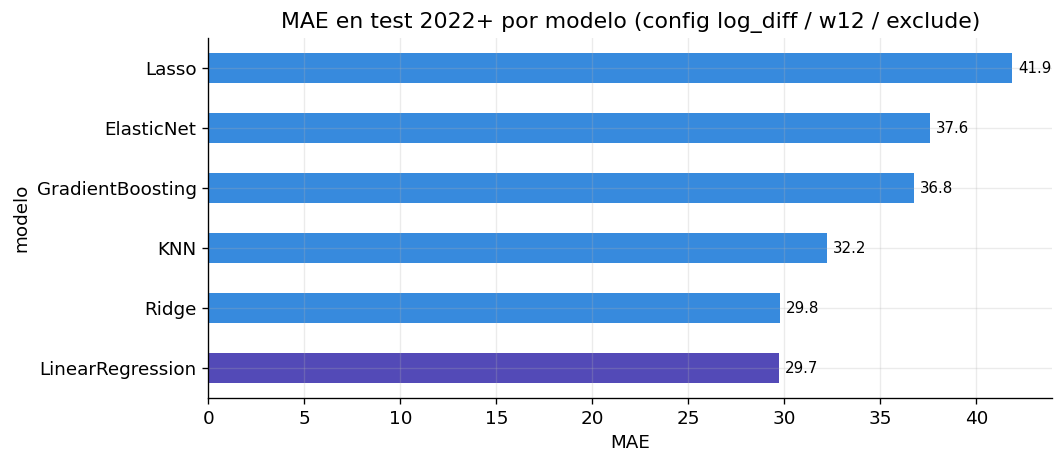

In [8]:
# FIGURA: ranking de modelos en test (MAE)
fig, ax = plt.subplots(figsize=(9, 4))
d = fac_sin.set_index("modelo")["mae"].sort_values(ascending=True)
colors = [C["best"] if i==0 else C["blue"] for i in range(len(d))]
d.plot(kind="barh", ax=ax, color=colors)
ax.set(title="MAE en test 2022+ por modelo (config log_diff / w12 / exclude)", xlabel="MAE")
for i,(m,v) in enumerate(d.items()):
    ax.text(v+0.3, i, f"{v:.1f}", va="center", fontsize=9)
plt.savefig(f"{FIG}/fig_ranking_test.png", bbox_inches="tight")
plt.show()

## 6. Evaluacion en test reproducida con el paquete

Para garantizar que los numeros del reporte coinciden exactamente con el
codigo, reevaluamos la config ganadora con `evaluate_on_test` del paquete.
(Si el entorno no tiene el paquete instalado, se omite y se usan las metricas
ya guardadas en `best_config.json`.)

In [9]:
try:
    from berry_price_tda.pipelines.optimize import evaluate_on_test
    from berry_price_tda.pipelines.evaluate import RunConfig

    rc_sin = RunConfig(model_name=cfg_sin["model_name"], window=cfg_sin["window"],
                       transform=cfg_sin["transform"], exog_cols=cfg_sin["exog_cols"],
                       use_tda=cfg_sin["use_tda"], strategy=cfg_sin["strategy"])
    m = evaluate_on_test(DATA, rc_sin)
    print("Reevaluado en test (sin exog):", {k:round(v,3) for k,v in m.items()})
    print("Guardado en json          :", {k:round(v,3) for k,v in cfg_sin["test_metrics"].items()})
except Exception as e:
    print("Paquete no disponible, uso metricas guardadas:", e)
    print(cfg_sin["test_metrics"])

Reevaluado en test (sin exog): {'mae': 29.79, 'rmse': 37.093, 'mape': 21.519, 'r2': 0.469}
Guardado en json          : {'mae': 29.79, 'rmse': 37.093, 'mape': 21.519, 'r2': 0.469}
